First five records:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Message Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


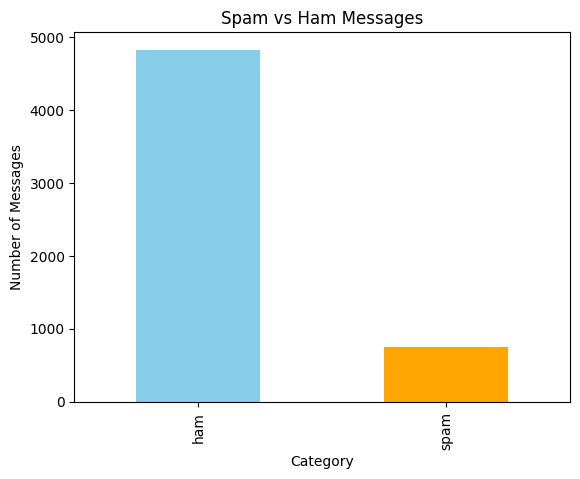


Most common words in spam messages:
[('to', 686), ('a', 378), ('call', 350), ('you', 287), ('your', 263), ('free', 219), ('for', 204), ('the', 204), ('now', 190), ('or', 188)]
                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  

TF-IDF Matrix Shape: (5572, 3000)

Model Performance
Accuracy : 0.9524663677130045
Precision: 0.9619047619047619
Recall   : 0.6733333333333333
F1 Score : 0

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:

# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

# Reading dataset
data = pd.read_csv("spam.csv", encoding="latin-1")

# Keep only the required columns
data = data[["v1", "v2"]]
data.columns = ["label", "message"]

# Display first few rows
print("First five records:")
print(data.head())

# Check number of spam and ham messages
print("\nMessage Distribution:")
print(data["label"].value_counts())

# Plot the distribution
data["label"].value_counts().plot(
    kind="bar",
    color=["skyblue", "orange"]
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.show()

# Find the most common words in spam messages
spam_text = data[data["label"] == "spam"]["message"]
word_list = []

for text in spam_text:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    word_list.extend(text.split())

top_words = Counter(word_list).most_common(10)

print("\nMost common words in spam messages:")
print(top_words)

# Text preprocessing

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    # Remove links
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove numbers and punctuation
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    # Remove stop words
    filtered = [word for word in words if word not in stop_words]
    return " ".join(filtered)

# Apply preprocessing
data["clean_message"] = data["message"].apply(clean_text)
print(data[["message", "clean_message"]].head())

# Convert text into TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(data["clean_message"])

# Convert labels into numbers
y = data["label"].map({"ham": 0, "spam": 1})
print("\nTF-IDF Matrix Shape:", X.shape)

# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Predict test data
predictions = classifier.predict(X_test)


# Evaluate the model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
matrix = confusion_matrix(y_test, predictions)

print("\nModel Performance")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("\nConfusion Matrix")
print(matrix)